# ⚙️ Feature Engineering Deep Dive
We examine how rolling windows and derived features improve the signal.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.pipeline import build_full_pipeline

%matplotlib inline
sns.set_theme(style='whitegrid')

In [14]:
# Load the fully processed data (including all features)
df = build_full_pipeline(
    'data/synthetic/video_telemetry.csv',
    'data/synthetic/audio_telemetry.csv',
    'data/synthetic/system_events.csv',
    'data/synthetic/labels.csv'
)
print(f"Data shape: {df.shape}")
df.head()

Data shape: (600, 40)


,timestamp,eye_gaze_angle,head_pose_x,head_pose_y,face_detected,audio_db,copy_paste,tab_switch,tab_switches,is_cheating,...,audio_rolling_std_30s,gaze_ema_5,audio_ema_5,gaze_ema_10,audio_ema_10,gaze_ema_20,audio_ema_20,tab_switch_density,copy_paste_density,cumulative_risk_score
0,2026-06-26 09:25:20,2.483571,2.270966,0.375674,1,41.946238,0.0,NaN,0.0,0,...,0.000000,2.483571,41.946238,2.483571,41.946238,2.483571,41.946238,0.0,0.0,0.0
1,2026-06-26 09:25:21,-0.691322,-2.766496,-1.288217,1,40.576476,0.0,NaN,0.0,0,...,0.968568,1.425273,41.489651,1.906318,41.697191,2.181200,41.815785,0.0,0.0,0.0
2,2026-06-26 09:25:22,3.238443,2.608818,0.366893,1,43.424480,0.0,NaN,0.0,0,...,1.424346,2.029663,42.134594,2.148522,42.011243,2.281890,41.968994,0.0,0.0,0.0
3,2026-06-26 09:25:23,7.615149,4.066914,1.629894,1,42.702477,0.0,NaN,0.0,0,...,1.217430,3.891492,42.323888,3.142454,42.136922,2.789819,42.038849,0.0,0.0,0.0
4,2026-06-26 09:25:24,-1.170767,1.240305,0.146580,1,49.664174,0.0,NaN,0.0,0,...,3.516656,2.204072,44.770650,2.358232,43.505513,2.412621,42.765071,0.0,0.0,0.0


In [17]:
# List of new features added by the pipeline
new_cols = [col for col in df.columns if 'rolling' in col or 'ema' in col or 'density' in col or 'deviation' in col or 'velocity' in col or 'acceleration' in col]
print("New features:", new_cols)

New features: ['gaze_deviation', 'head_velocity_x', 'head_velocity_y', 'head_acceleration_x', 'head_acceleration_y', 'gaze_rolling_mean_5s', 'gaze_rolling_std_5s', 'audio_rolling_mean_5s', 'audio_rolling_std_5s', 'gaze_rolling_mean_10s', 'gaze_rolling_std_10s', 'audio_rolling_mean_10s', 'audio_rolling_std_10s', 'gaze_rolling_mean_15s', 'gaze_rolling_std_15s', 'audio_rolling_mean_15s', 'audio_rolling_std_15s', 'gaze_rolling_mean_30s', 'gaze_rolling_std_30s', 'audio_rolling_mean_30s', 'audio_rolling_std_30s', 'gaze_ema_5', 'audio_ema_5', 'gaze_ema_10', 'audio_ema_10', 'gaze_ema_20', 'audio_ema_20', 'tab_switch_density', 'copy_paste_density']


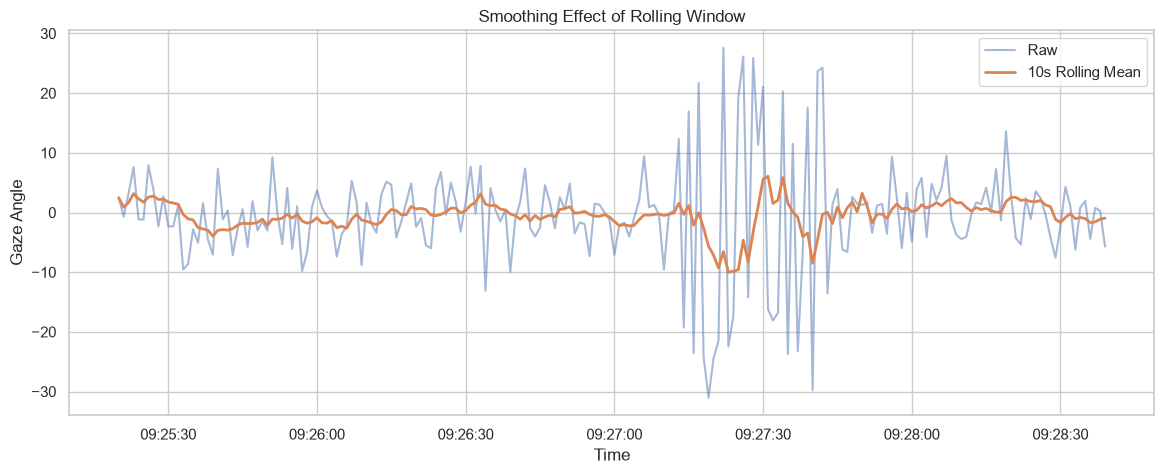

In [18]:
# Compare raw gaze vs. smoothed rolling mean
plt.figure(figsize=(14,5))
plt.plot(df['timestamp'][:200], df['eye_gaze_angle'][:200], alpha=0.5, label='Raw')
plt.plot(df['timestamp'][:200], df['gaze_rolling_mean_10s'][:200], linewidth=2, label='10s Rolling Mean')
plt.xlabel('Time')
plt.ylabel('Gaze Angle')
plt.legend()
plt.title('Smoothing Effect of Rolling Window')
plt.show()

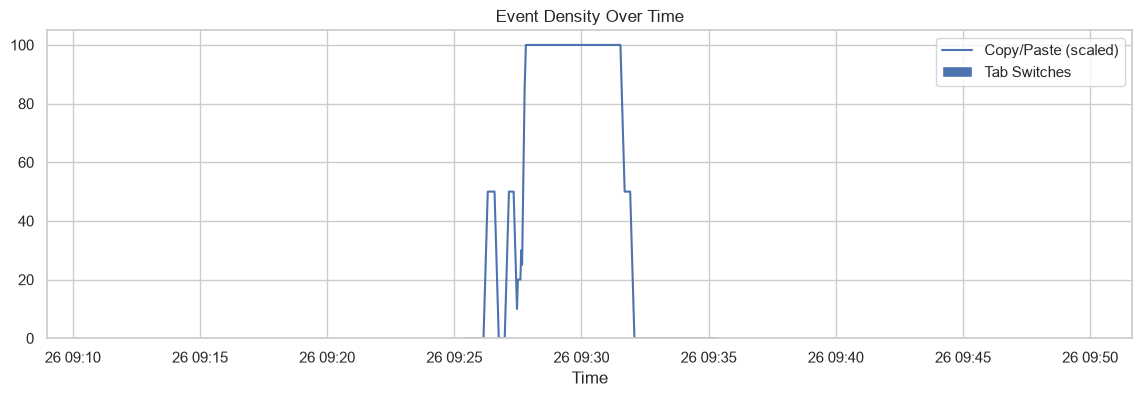

In [19]:
# Event density over time
plt.figure(figsize=(14,4))
plt.bar(df['timestamp'], df['tab_switch_density'], width=0.02, label='Tab Switches')
plt.plot(df['timestamp'], df['copy_paste_density']*5, label='Copy/Paste (scaled)')
plt.xlabel('Time')
plt.legend()
plt.title('Event Density Over Time')
plt.show()

In [20]:
# Feature importance from a quick RandomForest (to see which new features matter)
from sklearn.ensemble import RandomForestClassifier
from src.ml.train import get_features_target

X, y = get_features_target(df)
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

audio_rolling_mean_5s     0.183539
gaze_rolling_std_5s       0.140706
audio_ema_10              0.094761
gaze_deviation            0.088388
gaze_rolling_std_10s      0.079307
gaze_rolling_std_15s      0.063648
audio_db                  0.062602
audio_ema_5               0.049584
audio_rolling_mean_30s    0.037014
head_pose_x               0.033441
dtype: float64

**Key takeaways:**
- Rolling windows effectively smooth out noise.
- Event density features (tab switches, copy/paste) capture suspicious patterns.
- Derived features (gaze deviation, head velocity) add predictive power.
- Many rolling features show strong correlation with the target.